✅ Dataset Generated
   Shape: (2000, 11)
   Class distribution:
creditworthy
0    1463
1     537
Name: count, dtype: int64

📊 Logistic Regression
   Accuracy:  0.8525
   F1-Score:  0.7065
   ROC-AUC:   0.8992

📊 Decision Tree
   Accuracy:  0.8025
   F1-Score:  0.6146
   ROC-AUC:   0.8112

📊 Random Forest
   Accuracy:  0.8175
   F1-Score:  0.5731
   ROC-AUC:   0.8828

✅ Dashboard saved!

🏆 Best Model: Logistic Regression
   ROC-AUC: 0.8992

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

  Bad Credit       0.83      0.95      0.88       293
 Good Credit       0.77      0.46      0.57       107

    accuracy                           0.82       400
   macro avg       0.80      0.70      0.73       400
weighted avg       0.81      0.82      0.80       400



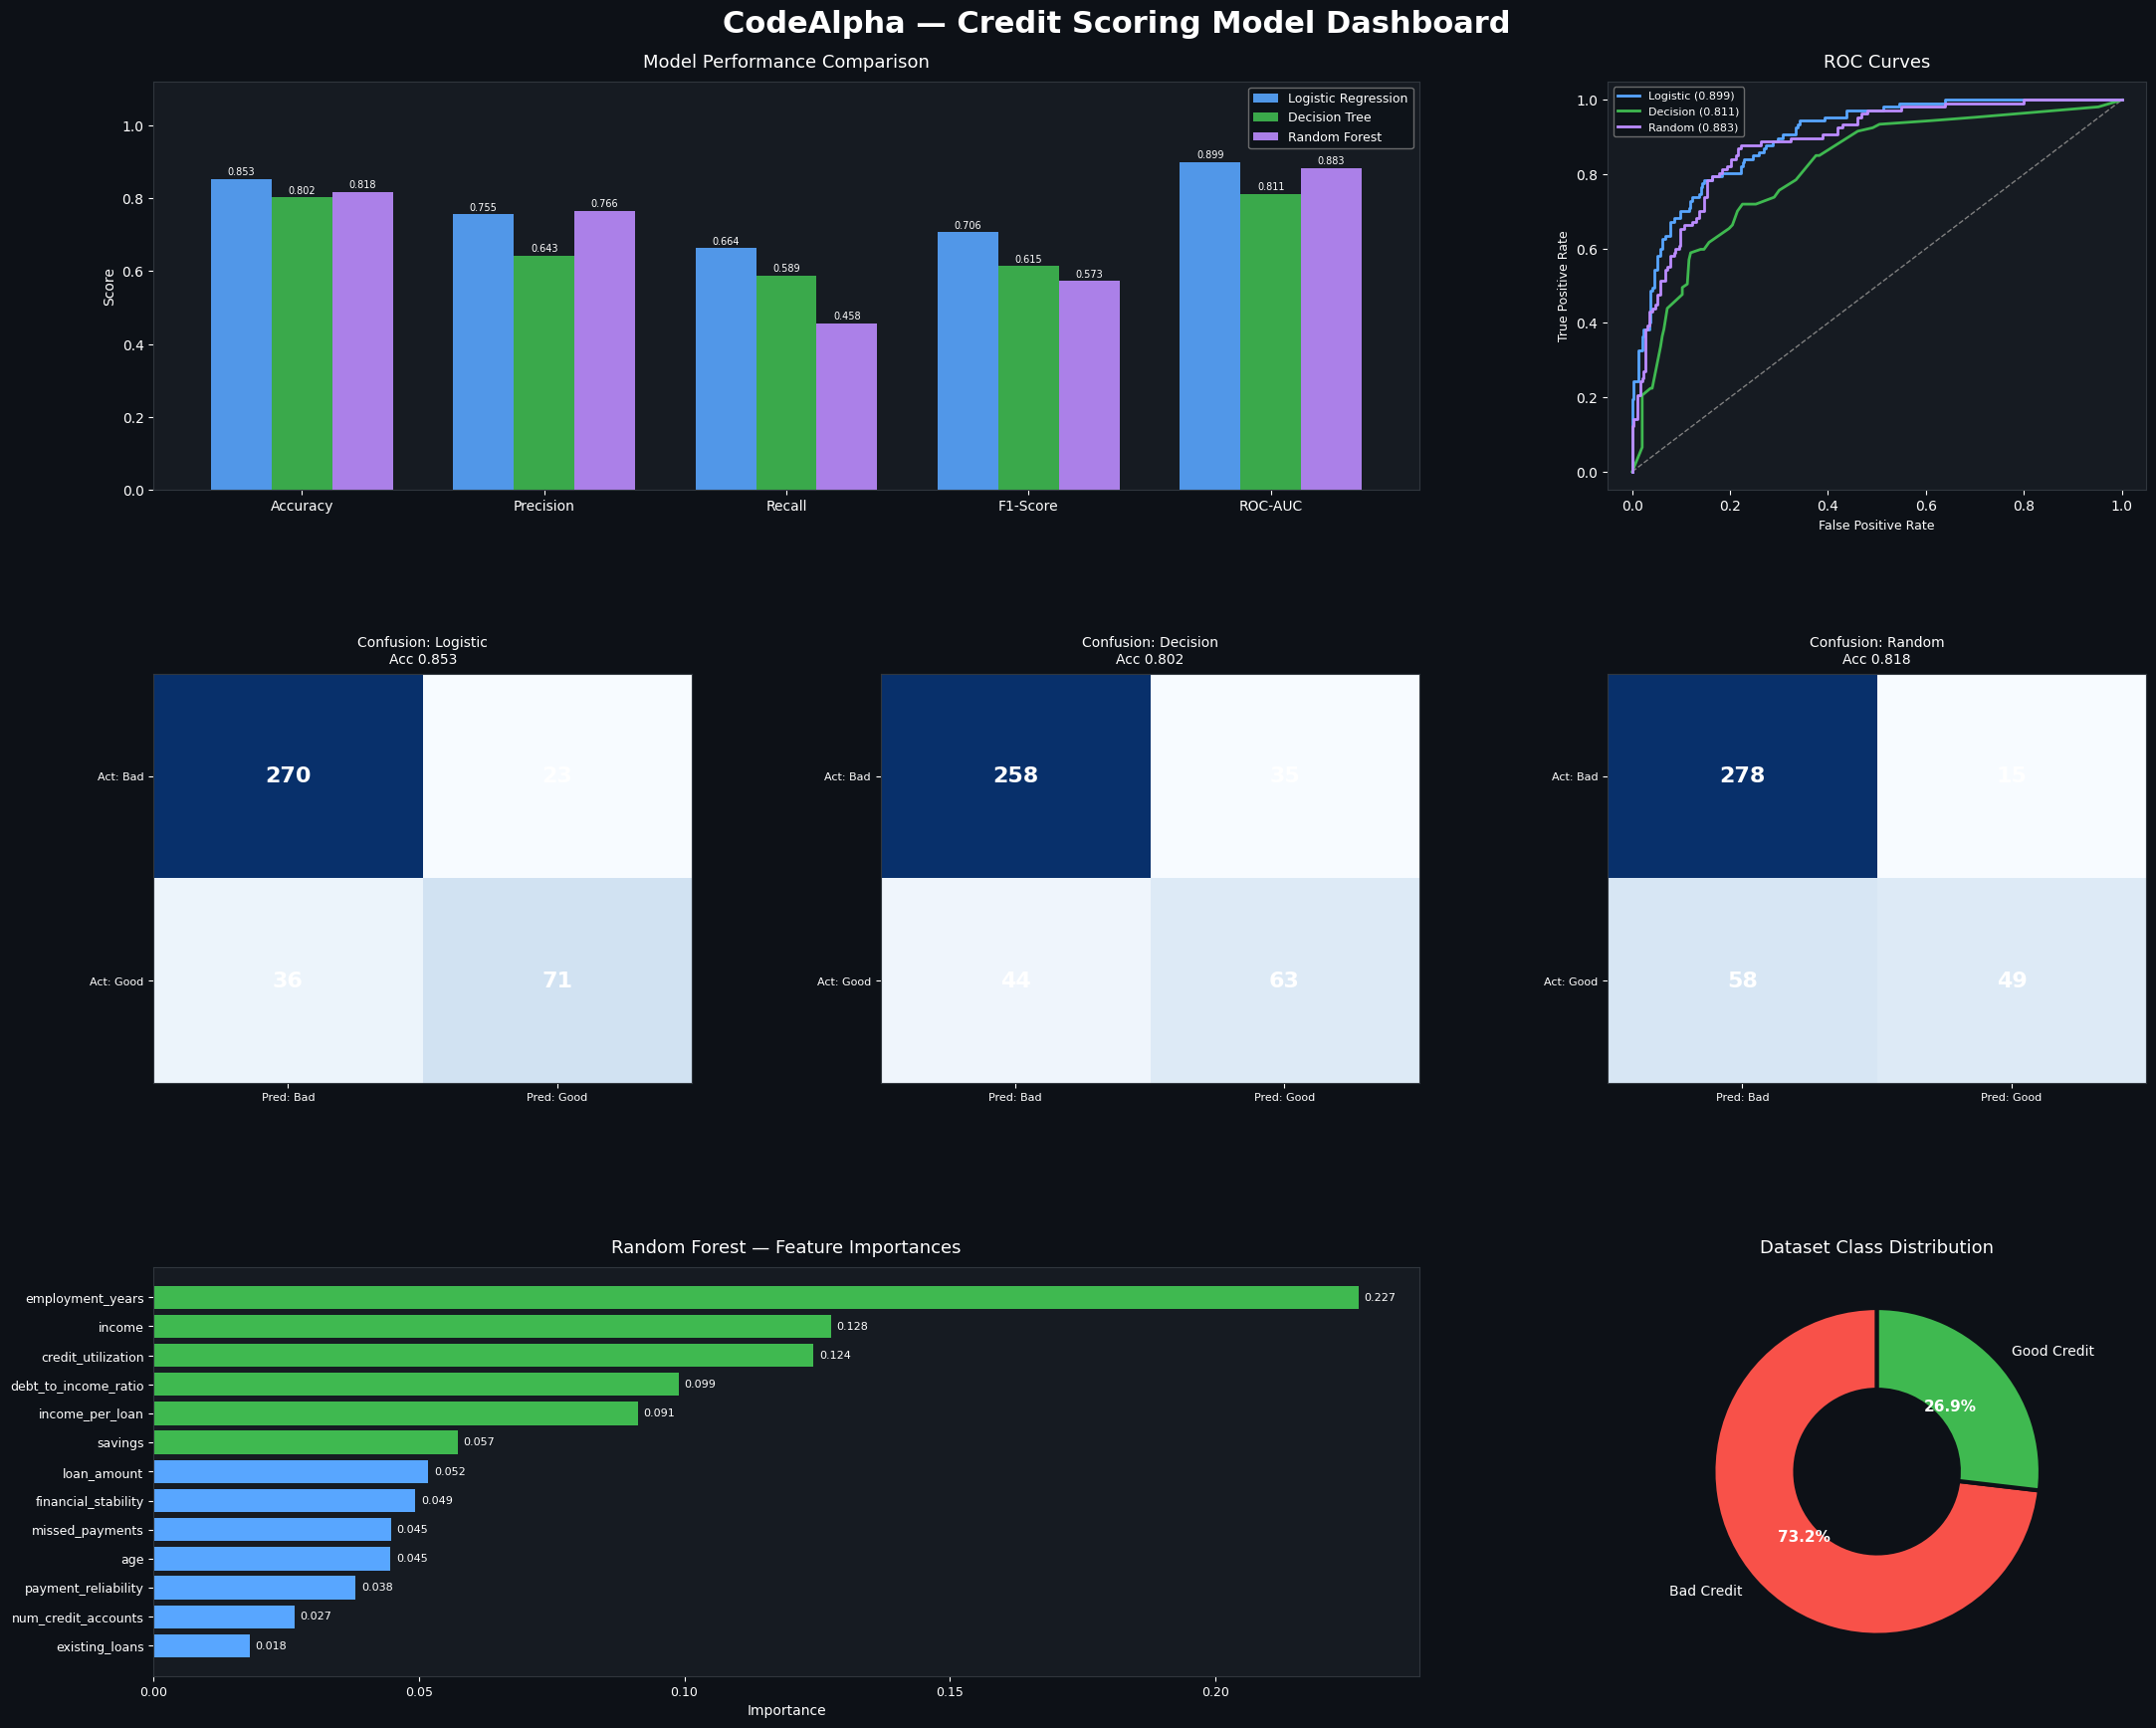

In [2]:
"""
CodeAlpha Internship - Task 1: Credit Scoring Model
Author: [Aditya Basu ]
Description: Predict creditworthiness using classification algorithms
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# 1. GENERATE SYNTHETIC DATASET
# ─────────────────────────────────────────────
np.random.seed(42)
n_samples = 2000

def generate_credit_data(n):
    age = np.random.randint(21, 70, n)
    income = np.random.normal(55000, 20000, n).clip(15000, 200000)
    loan_amount = np.random.normal(12000, 7000, n).clip(1000, 60000)
    debt_to_income = loan_amount / income + np.random.normal(0, 0.05, n)
    num_credit_accounts = np.random.randint(1, 15, n)
    missed_payments = np.random.poisson(0.8, n)
    employment_years = np.random.randint(0, 30, n)
    credit_utilization = np.random.beta(2, 5, n)
    existing_loans = np.random.randint(0, 5, n)
    savings = np.random.normal(15000, 10000, n).clip(0, 100000)

    # Creditworthiness score (0 = bad, 1 = good)
    score = (
        0.25 * (income / 200000)
        + 0.20 * (1 - missed_payments.clip(0, 5) / 5)
        + 0.15 * (employment_years / 30)
        + 0.15 * (1 - credit_utilization)
        + 0.10 * (savings / 100000)
        - 0.15 * debt_to_income.clip(0, 1)
        + np.random.normal(0, 0.05, n)
    )
    creditworthy = (score > 0.45).astype(int)

    return pd.DataFrame({
        'age': age,
        'income': income.astype(int),
        'loan_amount': loan_amount.astype(int),
        'debt_to_income_ratio': debt_to_income.round(3),
        'num_credit_accounts': num_credit_accounts,
        'missed_payments': missed_payments,
        'employment_years': employment_years,
        'credit_utilization': credit_utilization.round(3),
        'existing_loans': existing_loans,
        'savings': savings.astype(int),
        'creditworthy': creditworthy
    })

df = generate_credit_data(n_samples)
print("✅ Dataset Generated")
print(f"   Shape: {df.shape}")
print(f"   Class distribution:\n{df['creditworthy'].value_counts()}")

# ─────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────
df['income_per_loan'] = (df['income'] / df['loan_amount']).round(3)
df['payment_reliability'] = (1 / (df['missed_payments'] + 1)).round(3)
df['financial_stability'] = ((df['savings'] / df['income']) * 100).round(2)

features = [
    'age', 'income', 'loan_amount', 'debt_to_income_ratio',
    'num_credit_accounts', 'missed_payments', 'employment_years',
    'credit_utilization', 'existing_loans', 'savings',
    'income_per_loan', 'payment_reliability', 'financial_stability'
]
target = 'creditworthy'

X = df[features]
y = df[target]

# ─────────────────────────────────────────────
# 3. SPLIT & SCALE
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 4. TRAIN MODELS
# ─────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
}

results = {}
for name, model in models.items():
    use_scaled = name == 'Logistic Regression'
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'use_scaled': use_scaled
    }
    print(f"\n📊 {name}")
    print(f"   Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"   F1-Score:  {results[name]['f1']:.4f}")
    print(f"   ROC-AUC:   {results[name]['roc_auc']:.4f}")

# ─────────────────────────────────────────────
# 5. PLOTS
# ─────────────────────────────────────────────
plt.style.use('dark_background')
DARK   = '#0d1117'
PANEL  = '#161b22'
ACCENT = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f85149'
PURPLE = '#bc8cff'
GOLD   = '#e3b341'
COLORS = [ACCENT, GREEN, PURPLE]

fig = plt.figure(figsize=(22, 18), facecolor=DARK)
fig.suptitle('CodeAlpha — Credit Scoring Model Dashboard',
             fontsize=22, fontweight='bold', color='white', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35,
                      left=0.06, right=0.97, top=0.94, bottom=0.05)

# ── A: Model Comparison Bar Chart ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(PANEL)
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    bars = ax1.bar(x + i*width, vals, width, label=name, color=COLORS[i], alpha=0.9, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7, color='white')

ax1.set_xticks(x + width)
ax1.set_xticklabels(metric_labels, color='white', fontsize=10)
ax1.set_ylim(0, 1.12)
ax1.set_title('Model Performance Comparison', color='white', fontsize=13, pad=10)
ax1.legend(facecolor=DARK, edgecolor='gray', labelcolor='white', fontsize=9)
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#30363d')
ax1.set_ylabel('Score', color='white')

# ── B: ROC Curves ──
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PANEL)
ax2.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
for (name, res), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax2.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name.split()[0]} ({res['roc_auc']:.3f})")
ax2.set_title('ROC Curves', color='white', fontsize=13, pad=10)
ax2.set_xlabel('False Positive Rate', color='white', fontsize=9)
ax2.set_ylabel('True Positive Rate', color='white', fontsize=9)
ax2.legend(facecolor=DARK, edgecolor='gray', labelcolor='white', fontsize=8)
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#30363d')

# ── C: Confusion Matrices ──
for idx, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, idx])
    ax.set_facecolor(PANEL)
    cm = confusion_matrix(y_test, res['y_pred'])
    cmap = plt.cm.Blues
    im = ax.imshow(cm, cmap=cmap, aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred: Bad','Pred: Good'], color='white', fontsize=8)
    ax.set_yticklabels(['Act: Bad','Act: Good'], color='white', fontsize=8)
    ax.set_title(f'Confusion: {name.split()[0]}\nAcc {res["accuracy"]:.3f}',
                 color='white', fontsize=10, pad=8)
    ax.spines[:].set_color('#30363d')

# ── D: Feature Importances (Random Forest) ──
ax5 = fig.add_subplot(gs[2, :2])
ax5.set_facecolor(PANEL)
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
colors_feat = [GREEN if v > importances.median() else ACCENT for v in importances]
bars = ax5.barh(importances.index, importances.values, color=colors_feat, edgecolor='none')
ax5.set_title('Random Forest — Feature Importances', color='white', fontsize=13, pad=10)
ax5.tick_params(colors='white', labelsize=9)
ax5.spines[:].set_color('#30363d')
ax5.set_xlabel('Importance', color='white')
for bar, val in zip(bars, importances.values):
    ax5.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', color='white', fontsize=8)

# ── E: Class Distribution ──
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor(PANEL)
counts = df['creditworthy'].value_counts()
wedge_props = dict(width=0.5, edgecolor=DARK, linewidth=3)
wedges, texts, autotexts = ax6.pie(
    counts, labels=['Bad Credit', 'Good Credit'],
    autopct='%1.1f%%', colors=[RED, GREEN],
    wedgeprops=wedge_props, startangle=90,
    textprops={'color': 'white', 'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax6.set_title('Dataset Class Distribution', color='white', fontsize=13, pad=10)

plt.savefig('/credit_scoring_dashboard.png',
            dpi=150, bbox_inches='tight', facecolor=DARK)
print("\n✅ Dashboard saved!")

# ─────────────────────────────────────────────
# 6. PRINT FINAL REPORT
# ─────────────────────────────────────────────
best = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\n🏆 Best Model: {best}")
print(f"   ROC-AUC: {results[best]['roc_auc']:.4f}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT — Random Forest")
print("="*50)
print(classification_report(y_test, results['Random Forest']['y_pred'],
                            target_names=['Bad Credit', 'Good Credit']))

